# Proyek: Analisis Data Rantai Pasokan (*supply chains*)

Proyek ini merupakan analisis menyeluruh terhadap data rantai pasokan untuk mengevaluasi efisiensi logistik, kinerja finansial, kualitas produk, dan keandalan pemasok. Proses ini menggunakan bahasa pemrograman Python serta pustaka analisis data pendukung untuk menghasilkan wawasan bisnis yang dapat ditindaklanjuti

## Rumusan Pertanyaan


1. Kategori produk apa yang menjadi profitabilitas utama perusahaan, dan bagaimana kontribusinya terhadap total volume penjualan?
2. Titik lokasi mana yang menjadi hambatan (*bottleneck*) terbesar dalam rantai pasok kita berdasarkan tingkat keterlambatan dan biaya?
3. Apakah ada pemasok (*supplier*) yang kinerjanya di bawah standar mutu sehingga berisiko merugikan perusahaan?
4. Produk spesifik (SKU) mana yang paling mendesak untuk segera ditarik atau diperbaiki mutu produksinya?
5. Kombinasi rute dan layanan ekspedisi mana yang paling membebani anggaran operasional logistik?

## Install dan Import Library

In [127]:
!pip install kagglehub matplotlib pandas seaborn -q

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Mengatur tema visualisasi
sns.set_theme(style="whitegrid")

print("Library berhasil diimport!")

Library berhasil diimport!


## Download Dataset dari Kaggle via kagglehub

In [128]:
path = kagglehub.dataset_download("harshsingh2209/supply-chain-analysis")

# Deteksi lokasi berkas CSV
berkas_csv = [f for f in os.listdir(path) if f.endswith('.csv')][0]
path_lengkap = os.path.join(path, berkas_csv)

# Muat data ke dalam DataFrame
df_raw = pd.read_csv(path_lengkap)
print(f"Dataset berhasil dimuat dari: {path_lengkap}")

Using Colab cache for faster access to the 'supply-chain-analysis' dataset.
Dataset berhasil dimuat dari: /kaggle/input/supply-chain-analysis/supply_chain_data.csv


## Cek Tipe Data dan Struktur Data Mentah

In [129]:
print("=== JUMLAH BARIS DAN KOLOM ===")
print(f"Bentuk dataset (Baris, Kolom): {df_raw.shape}\n")

print("=== INFORMASI TIPE DATA SETIAP KOLOM ===")
df_raw.info()

=== JUMLAH BARIS DAN KOLOM ===
Bentuk dataset (Baris, Kolom): (100, 24)

=== INFORMASI TIPE DATA SETIAP KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs       

## Pemeriksaan Kualitas Data dan Ringkasan Statistik

In [130]:
print("=== RINGKASAN STATISTIK KOLOM NUMERIK ===")
display(df_raw.describe())

print("\n=== RINGKASAN STATISTIK KOLOM KATEGORIKAL ===")
display(df_raw.describe(include='object'))

print("\n=== PEMERIKSAAN KUALITAS DATA ===")
print(f"Total Baris Kosong (Null) di seluruh data : {df_raw.isnull().sum().sum()}")
print(f"Total Baris Duplikat                      : {df_raw.duplicated().sum()}")

=== RINGKASAN STATISTIK KOLOM NUMERIK ===


,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450



=== RINGKASAN STATISTIK KOLOM KATEGORIKAL ===


,Product type,SKU,Customer demographics,Shipping carriers,Supplier name,Location,Inspection results,Transportation modes,Routes
count,100,100,100,100,100,100,100,100,100
unique,3,100,4,3,5,5,3,4,3
top,skincare,SKU0,Unknown,Carrier B,Supplier 1,Kolkata,Pending,Road,Route A
freq,40,1,31,43,27,25,41,29,43



=== PEMERIKSAAN KUALITAS DATA ===
Total Baris Kosong (Null) di seluruh data : 0
Total Baris Duplikat                      : 0


## Data Cleaning & Feature Engineering

In [131]:
df = df_raw.copy()
df = df.drop_duplicates()

# Standarisasi Nama Kolom Utama[span_0](start_span)[span_0](end_span)
df['Order Country'] = df['Location']
df['Shipping Mode'] = df['Transportation modes']
df['Sales'] = df['Revenue generated']
df['Costs'] = df['Costs']
df['Days for shipping (real)'] = df['Shipping times']
df['Days for shipment (scheduled)'] = df['Manufacturing lead time']

# Kalkulasi Profit dan Delay
df['Order Profit Per Order'] = df['Sales'] - df['Costs']
df['Delay_Days'] = (df['Days for shipping (real)'] - df['Days for shipment (scheduled)']).clip(lower=0)
df['Delivery Status'] = df['Delay_Days'].apply(lambda x: 'Late delivery' if x > 0 else 'Shipping on time')

print("Data cleaning & feature engineering selesai!")

Data cleaning & feature engineering selesai!


## Analisis Data Eksploratif & Agregasi Metrik (Exploratory Data Analysis & Metrics Aggregation)

### Review Data


In [132]:
print("=== PREVIEW 10 BARIS PERTAMA DARI DATA ===")

# Menampilkan seluruh kolom agar tidak ada yang terpotong (...)
pd.set_option('display.max_columns', None)
display(df.head(10))

=== PREVIEW 10 BARIS PERTAMA DARI DATA ===


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,Order Country,Shipping Mode,Sales,Days for shipping (real),Days for shipment (scheduled),Order Profit Per Order,Delay_Days,Delivery Status
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,Mumbai,Road,8661.996792,4,29,8474.244717,0,Shipping on time
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,Mumbai,Road,7460.900065,2,30,6957.834486,0,Shipping on time
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282,Mumbai,Air,9577.749626,2,27,9435.829344,0,Shipping on time
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,Kolkata,Rail,7766.836426,6,18,7512.060266,0,Shipping on time
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,Delhi,Air,2686.505152,8,3,1763.064520,5,Late delivery
5,haircare,SKU5,1.699976,87,147,2828.348746,Non-binary,90,27,66,3,Carrier B,4.444099,Supplier 4,Bangalore,10,104,17,56.766476,Fail,2.779194,Road,Route A,235.461237,Bangalore,Road,2828.348746,3,17,2592.887509,0,Shipping on time
6,skincare,SKU6,4.078333,48,65,7823.476560,Male,11,15,58,8,Carrier C,3.880763,Supplier 3,Kolkata,14,314,24,1.085069,Pending,1.000911,Sea,Route A,134.369097,Kolkata,Sea,7823.476560,8,24,7689.107463,0,Shipping on time
7,cosmetics,SKU7,42.958384,59,426,8496.103813,Female,93,17,11,1,Carrier B,2.348339,Supplier 4,Bangalore,22,564,1,99.466109,Fail,0.398177,Road,Route C,802.056312,Bangalore,Road,8496.103813,1,1,7694.047501,0,Shipping on time
8,cosmetics,SKU8,68.717597,78,150,7517.363211,Female,5,10,15,7,Carrier C,3.404734,Supplier 4,Mumbai,13,769,8,11.423027,Pending,2.709863,Sea,Route B,505.557134,Mumbai,Sea,7517.363211,7,8,7011.806076,0,Shipping on time
9,skincare,SKU9,64.015733,35,980,4971.145988,Unknown,14,27,83,1,Carrier A,7.166645,Supplier 2,Chennai,29,963,23,47.957602,Pending,3.844614,Rail,Route B,995.929461,Chennai,Rail,4971.145988,1,23,3975.216526,0,Shipping on time


### Agregasi Metrik

In [133]:
# Menyiapkan Data Finansial
# Evaluasi profitabilitas dan Volume Penjualan per Kategori)
df_finansial = df.groupby('Product type').agg(
    Total_Profit=('Order Profit Per Order', 'sum'),
    Total_Volume=('Number of products sold', 'sum')
).reset_index()

print("\n Ringkasan Finansial (Profit dan Volume per Produk):")
display(df_finansial)


 Ringkasan Finansial (Profit dan Volume per Produk):


,Product type,Total_Profit,Total_Volume
0,cosmetics,148154.868716,11757
1,haircare,157126.527741,13611
2,skincare,219398.844065,20731


In [134]:
# Analisis Logistik dan Pengiriman
# Evaluasi total pesanan, rata-rata keterlambatan, dan biaya kirim per negara.

df_logistik = df.groupby('Order Country').agg(
    Total_Pesanan=('SKU', 'count'),
    Rata_Rata_Delay=('Delay_Days', 'mean'),
    Rata_Biaya_Kirim=('Shipping costs', 'mean')
).reset_index().sort_values(by='Rata_Rata_Delay', ascending=False)

print("\n Analisis Logistik (Lokasi, Waktu Keterlambatan, dan Biaya Kirim):")
display(df_logistik)


 Analisis Logistik (Lokasi, Waktu Keterlambatan, dan Biaya Kirim):


,Order Country,Total_Pesanan,Rata_Rata_Delay,Rata_Biaya_Kirim
2,Delhi,15,1.000000,5.069881
0,Bangalore,18,0.444444,5.748445
3,Kolkata,25,0.440000,5.761414
1,Chennai,20,0.400000,4.689079
4,Mumbai,22,0.181818,6.248989


In [135]:
# Evaluasi Kualitas Produk
# Memeriksa tingkat kecacatan (defect rate) berdasarkan hasil inspeksi tiap produk.

df_kualitas = df.groupby(['Product type', 'Inspection results']).agg(
    Total_Kasus=('SKU', 'count'),
    Rata_Defect_Rate=('Defect rates', 'mean')
).reset_index().sort_values(by=['Product type', 'Rata_Defect_Rate'], ascending=[True, False])

print("\n Evaluasi Kualitas (Tingkat Cacat dan Hasil Inspeksi):")
display(df_kualitas)


 Evaluasi Kualitas (Tingkat Cacat dan Hasil Inspeksi):


,Product type,Inspection results,Total_Kasus,Rata_Defect_Rate
0,cosmetics,Fail,10,2.188127
1,cosmetics,Pass,6,1.819351
2,cosmetics,Pending,10,1.710409
4,haircare,Pass,6,2.924478
3,haircare,Fail,13,2.529315
5,haircare,Pending,15,2.266609
6,skincare,Fail,13,2.902501
8,skincare,Pending,16,2.326231
7,skincare,Pass,11,1.675910


In [136]:
# Penilaian Keandalan Pemasok (Supplier)
# Menilai performa supplier dari rata-rata waktu tunggu (lead time) dan tingkat kecacatan.

df_supplier = df.groupby('Supplier name').agg(
    Total_Pasokan=('SKU', 'count'),
    Rata_Lead_Time=('Lead times', 'mean'),
    Rata_Defect_Rate=('Defect rates', 'mean')
).reset_index().sort_values(by='Rata_Defect_Rate', ascending=True)

print("\n Keandalan Pemasok (Waktu Tunggu dan Tingkat Cacat):")
display(df_supplier)


 Keandalan Pemasok (Waktu Tunggu dan Tingkat Cacat):


,Supplier name,Total_Pasokan,Rata_Lead_Time,Rata_Defect_Rate
0,Supplier 1,27,16.777778,1.803630
3,Supplier 4,18,17.000000,2.337397
1,Supplier 2,22,16.227273,2.362750
2,Supplier 3,15,14.333333,2.465786
4,Supplier 5,18,14.722222,2.665408


In [137]:
# Tinjauan Inventaris dan Stok
# Meringkas rata-rata ketersediaan dan level stok saat ini per kategori produk.

df_inventaris = df.groupby('Product type').agg(
    Rata_Ketersediaan=('Availability', 'mean'),
    Rata_Level_Stok=('Stock levels', 'mean')
).reset_index()

print("\n Tinjauan Inventaris (Level Stok dan Ketersediaan):")
display(df_inventaris)


 Tinjauan Inventaris (Level Stok dan Ketersediaan):


,Product type,Rata_Ketersediaan,Rata_Level_Stok
0,cosmetics,51.230769,58.653846
1,haircare,43.264706,48.352941
2,skincare,50.925000,40.200000


In [138]:
# Pemetaan Pendapatan Berdasarkan Demografi Pelanggan
# Menghitung total pendapatan dari setiap kelompok demografi pelanggan dan jenis produk.

df_demografi = df.groupby(['Customer demographics', 'Product type']).agg(
    Total_Revenue=('Sales', 'sum')
).reset_index()

print("\n Pemetaan Demografi (Profil Pelanggan dan Pendapatan):")
display(df_demografi.head(6))


 Pemetaan Demografi (Profil Pelanggan dan Pendapatan):


,Customer demographics,Product type,Total_Revenue
0,Female,cosmetics,69548.542197
1,Female,haircare,12724.833283
2,Female,skincare,79241.113642
3,Male,cosmetics,21390.965497
4,Male,haircare,50599.927309
5,Male,skincare,54643.501453


In [139]:
# Evaluasi Rute dan Jasa Kurir Pengiriman
# Menilai jumlah pengiriman dan rata-rata biaya kirim berdasarkan kurir dan rute yang digunakan.

df_rute_kurir = df.groupby(['Shipping carriers', 'Routes']).agg(
    Total_Pengiriman=('SKU', 'count'),
    Rata_Biaya_Kirim=('Shipping costs', 'mean')
).reset_index()

print("\n Evaluasi Pengiriman (Kurir, Rute, dan Biaya):")
display(df_rute_kurir.head(6))


 Evaluasi Pengiriman (Kurir, Rute, dan Biaya):


,Shipping carriers,Routes,Total_Pengiriman,Rata_Biaya_Kirim
0,Carrier A,Route A,12,4.629630
1,Carrier A,Route B,13,6.227985
2,Carrier A,Route C,3,6.339489
3,Carrier B,Route A,17,5.530197
4,Carrier B,Route B,16,5.174455
5,Carrier B,Route C,10,6.009299


In [140]:
# Identifikasi Produk dengan Tingkat Cacat Tertinggi
# Menampilkan 5 produk (SKU) dengan persentase cacat paling tinggi beserta informasi pemasoknya.

df_sku_cacat = df[['SKU', 'Product type', 'Supplier name', 'Defect rates']]\
    .sort_values(by='Defect rates', ascending=False).head(5)

print("\n 5 Produk dengan Tingkat Cacat Tertinggi:")
display(df_sku_cacat)


 5 Produk dengan Tingkat Cacat Tertinggi:


,SKU,Product type,Supplier name,Defect rates
42,SKU42,skincare,Supplier 5,4.939255
65,SKU65,skincare,Supplier 5,4.911096
1,SKU1,skincare,Supplier 3,4.854068
84,SKU84,haircare,Supplier 5,4.843457
50,SKU50,cosmetics,Supplier 2,4.754801


## Visualisasi Grafik

/tmp/ipykernel_2903/844951675.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_finansial, x='Product type', y='Total_Volume', palette='Blues_r', ax=axes[1])


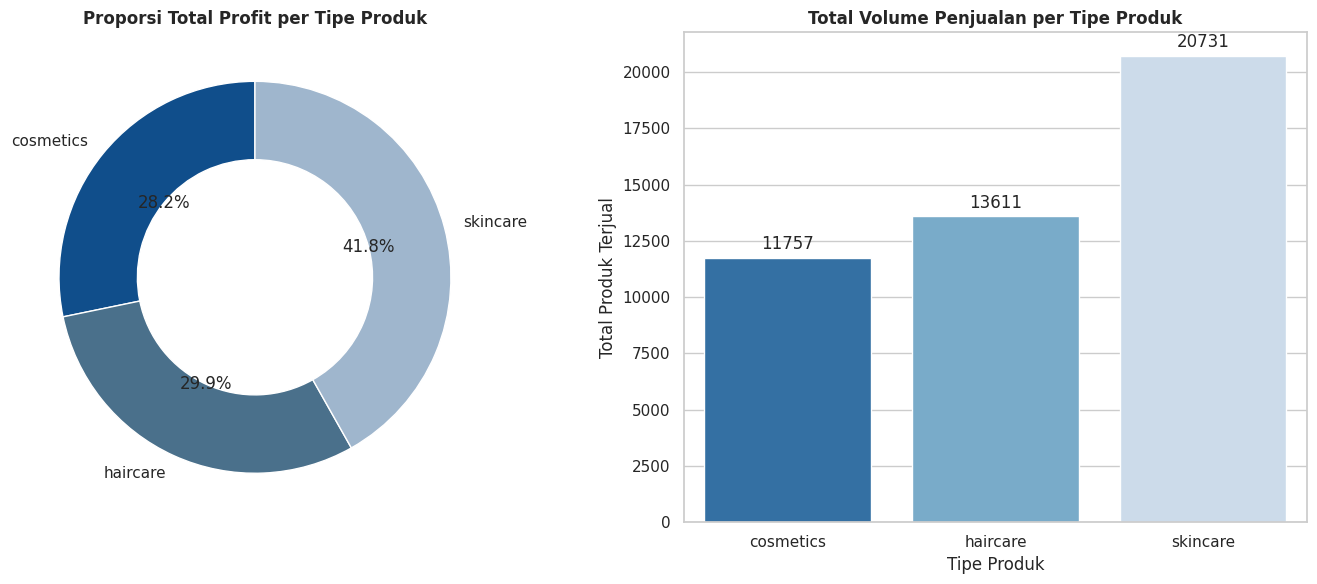

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    df_finansial['Total_Profit'],
    labels=df_finansial['Product type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#104E8B', '#4A708B', '#9FB6CD'],
    wedgeprops=dict(width=0.4, edgecolor='white')
)
axes[0].set_title('Proporsi Total Profit per Tipe Produk', fontweight='bold')

sns.barplot(data=df_finansial, x='Product type', y='Total_Volume', palette='Blues_r', ax=axes[1])
axes[1].set_title('Total Volume Penjualan per Tipe Produk', fontweight='bold')
axes[1].set_xlabel('Tipe Produk')
axes[1].set_ylabel('Total Produk Terjual')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

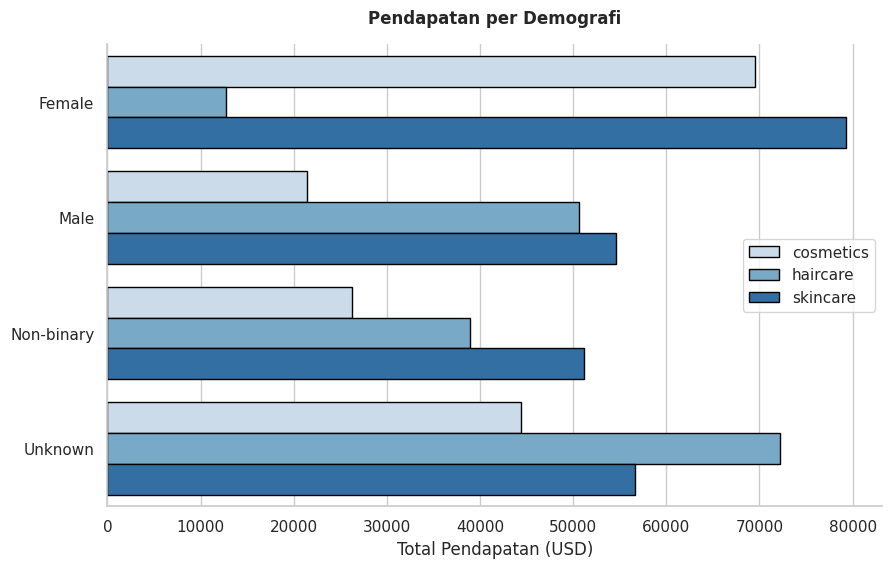

In [142]:
# 6. VISUALISASI DEMOGRAFI PENDAPATAN
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=tabel_demografi, x='Total_Revenue', y='Customer demographics', hue='Product type', palette='Blues', edgecolor='black', ax=ax)
ax.set_title('Pendapatan per Demografi', fontweight='bold', pad=15)
ax.set_xlabel('Total Pendapatan (USD)')
ax.set_ylabel('')
ax.legend(title='')

sns.despine()
plt.show()

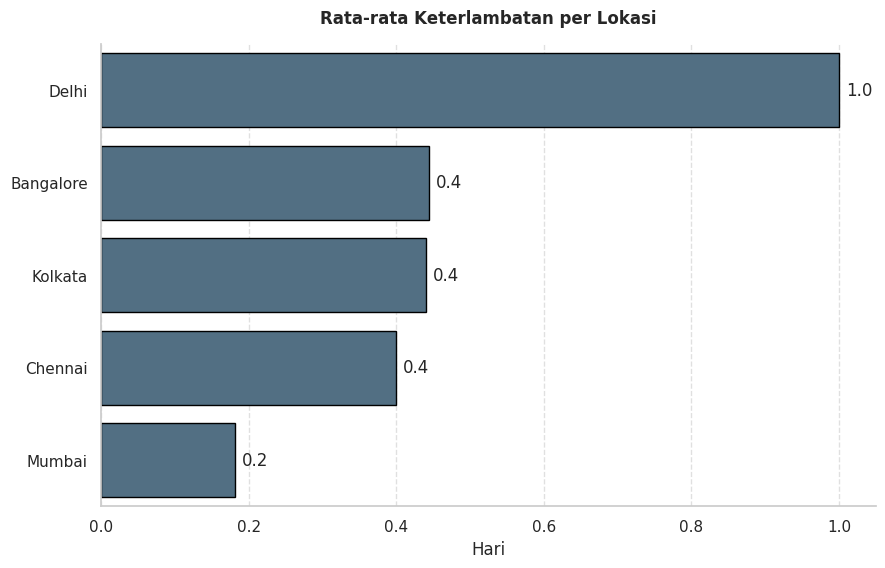

In [143]:
# 1. VISUALISASI LOGISTIK (Rata rata keterlambatan)
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=tabel_logistik, x='Rata_Rata_Delay', y='Order Country', color='#4A708B', edgecolor='black', ax=ax)
ax.set_title('Rata-rata Keterlambatan per Lokasi', fontweight='bold', pad=15)
ax.set_xlabel('Hari')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Menambahkan label angka
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5)

sns.despine()
plt.show()

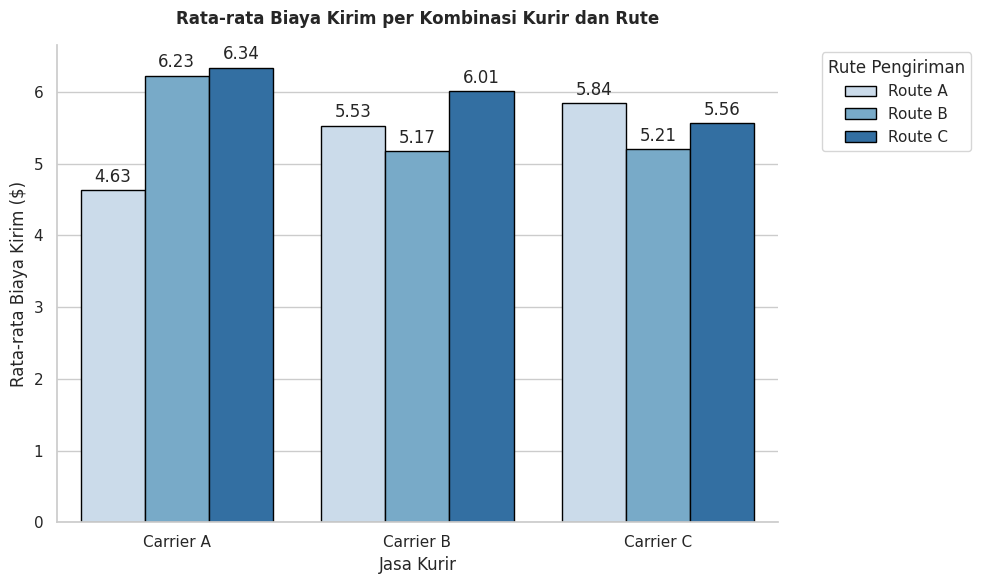

In [149]:
fig, ax = plt.subplots(figsize=(10, 6))

# Menggunakan df_rute_kurir yang sudah diagregasi sebelumnya
sns.barplot(
    data=df_rute_kurir,
    x='Shipping carriers',
    y='Rata_Biaya_Kirim',
    hue='Routes',
    palette='Blues',
    ax=ax,
    edgecolor='black'
)

ax.set_title('Rata-rata Biaya Kirim per Kombinasi Kurir dan Rute', fontweight='bold', pad=15)
ax.set_xlabel('Jasa Kurir')
ax.set_ylabel('Rata-rata Biaya Kirim ($)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.legend(title='Rute Pengiriman', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

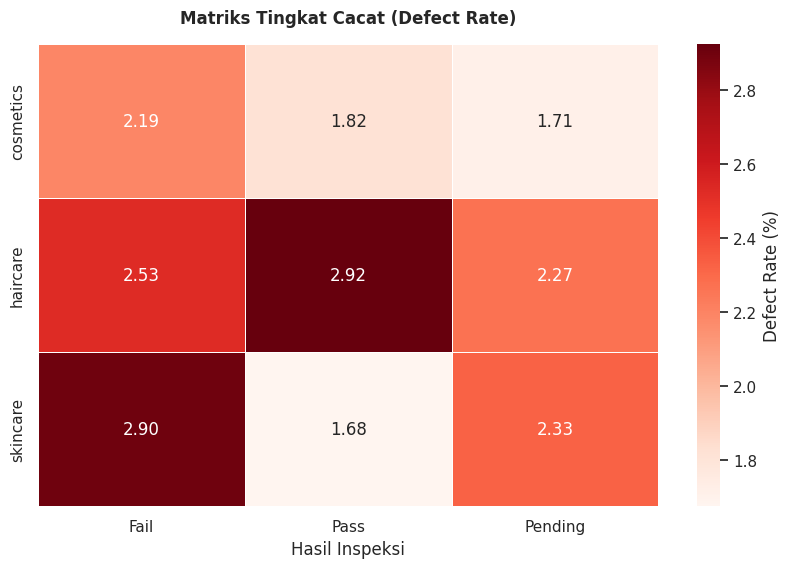

In [145]:
# 3. VISUALISASI KUALITAS (Matriks Tingkat Cacat)
fig, ax = plt.subplots(figsize=(10, 6))

tabel_kualitas_pivot = tabel_kualitas.pivot(index='Product type', columns='Inspection results', values='Rata_Defect_Rate').fillna(0)
sns.heatmap(tabel_kualitas_pivot, annot=True, fmt=".2f", cmap="Reds", linewidths=.5, ax=ax, cbar_kws={'label': 'Defect Rate (%)'})
ax.set_title('Matriks Tingkat Cacat (Defect Rate)', fontweight='bold', pad=15)
ax.set_ylabel('')
ax.set_xlabel('Hasil Inspeksi')

plt.show()

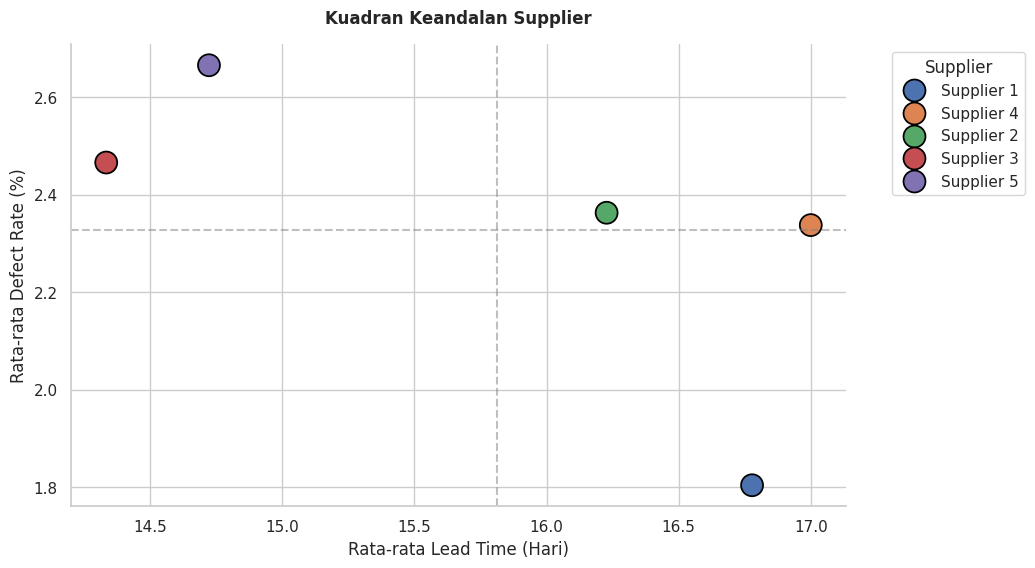

In [146]:
# 4. VISUALISASI KEANDALAN SUPPLIER (Kuadran Keandalan)
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=tabel_supplier, x='Rata_Lead_Time_Total', y='Rata_Defect_Rate', hue='Supplier name', s=250, palette='deep', edgecolor='black', ax=ax)

# Garis batas rata-rata untuk membagi kuadran (Bagus vs Buruk)
ax.axvline(tabel_supplier['Rata_Lead_Time_Total'].mean(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(tabel_supplier['Rata_Defect_Rate'].mean(), color='gray', linestyle='--', alpha=0.5)
ax.set_title('Kuadran Keandalan Supplier', fontweight='bold', pad=15)
ax.set_xlabel('Rata-rata Lead Time (Hari)')
ax.set_ylabel('Rata-rata Defect Rate (%)')
ax.legend(title='Supplier', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.show()

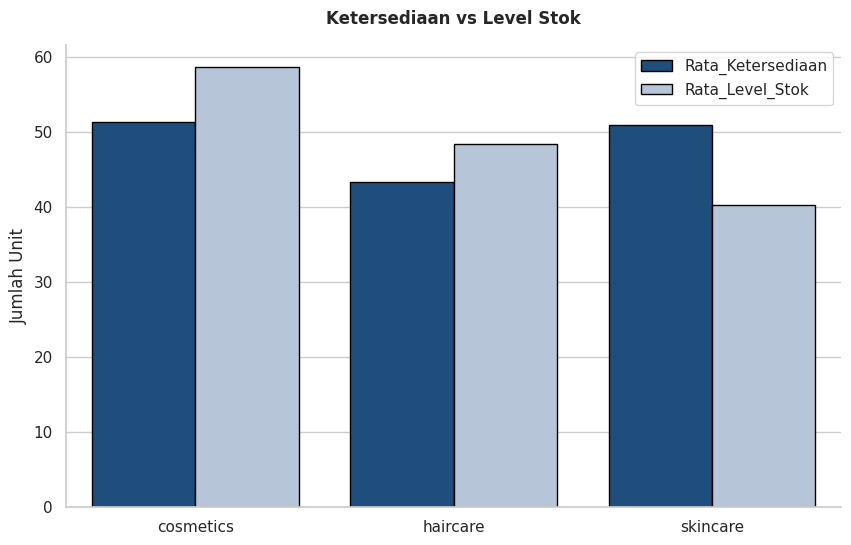

In [147]:
# 5. VISUALISASI INVENTARIS (Ketersediaan vs Level Stok)
fig, ax = plt.subplots(figsize=(10, 6))

tabel_inv_melt = tabel_inventaris.melt(id_vars='Product type', value_vars=['Rata_Ketersediaan', 'Rata_Level_Stok'], var_name='Metrik', value_name='Jumlah')
sns.barplot(data=tabel_inv_melt, x='Product type', y='Jumlah', hue='Metrik', palette=['#104E8B', '#B0C4DE'], edgecolor='black', ax=ax)

ax.set_title('Ketersediaan vs Level Stok', fontweight='bold', pad=15)
ax.set_ylabel('Jumlah Unit')
ax.set_xlabel('')
ax.legend(title='')

sns.despine()
plt.show()

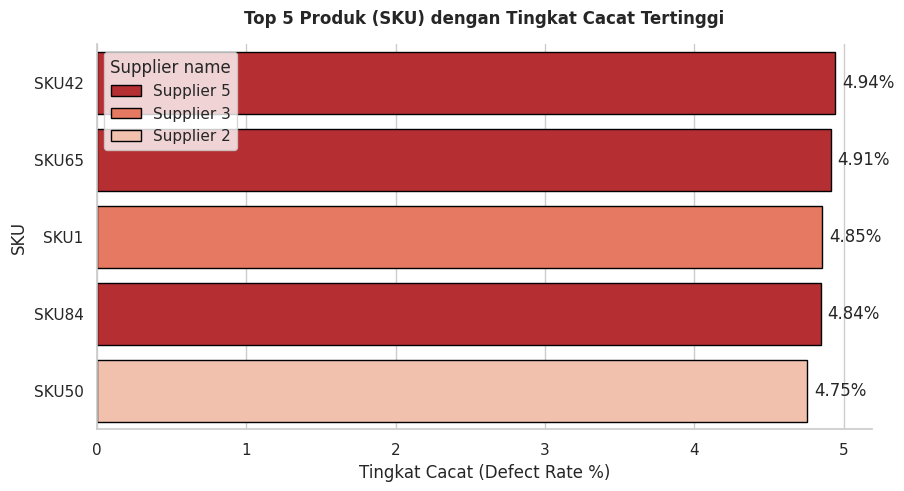

In [148]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=df_sku_cacat, x='Defect rates', y='SKU', hue='Supplier name', dodge=False, palette='Reds_r', edgecolor='black', ax=ax)
ax.set_title('Top 5 Produk (SKU) dengan Tingkat Cacat Tertinggi', fontweight='bold', pad=15)
ax.set_xlabel('Tingkat Cacat (Defect Rate %)')
ax.set_ylabel('SKU')

# Menambahkan label angka
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=5)

sns.despine()
plt.show()

## Menjawab Pertanyaan Bisnis & Kesimpulan Utama

Jawaban Pertanyaan Bisnis

1. Kategori produk apa yang menjadi profitabilitas utama perusahaan, dan bagaimana kontribusinya terhadap total volume penjualan?
Jawaban: Kategori produk Skincare menjadi kontributor utama profitabilitas perusahaan dengan sumbangan terbesar sebesar 41,8% serta mencatatkan volume penjualan tertinggi yang mencapai 20.731 unit. Sebaliknya, kategori Cosmetics menjadi penyumbang terendah, baik dari sisi proporsi profit sebesar 28,2% maupun volume penjualan yang hanya 11.757 unit. Sementara itu, posisi menengah diisi oleh kategori Haircare dengan proporsi profit 29,9% dan volume penjualan sebanyak 13.611 unit.

2. Titik lokasi mana yang menjadi hambatan terbesar dalam rantai pasok kita berdasarkan tingkat keterlambatan dan biaya?
Jawaban: Delhi memiliki kinerja waktu terburuk dengan rata-rata keterlambatan tertinggi 1,0 hari. Mumbai sangat cepat dengan keterlambatan 0,18 hari namun biaya pengirimannya tertinggi yaitu \$6,25.

3. Apakah ada pemasok (supplier) yang kinerjanya di bawah standar mutu sehingga berisiko merugikan perusahaan? Jawabannya adalah Supplier 5, yang memiliki rata-rata tingkat cacat produk tertinggi sebesar 2,66%. Meskipun demikian, waktu tunggu pengiriman Supplier 5 adalah 14,7 hari, yang lebih cepat dibandingkan dengan Supplier 4 yang memakan waktu 17,0 hari.

4. Produk spesifik (SKU) mana yang paling mendesak untuk segera ditarik atau diperbaiki mutu produksinya?
Jawaban: SKU42 dan SKU65 berada dalam status kritis karena tingkat cacatnya melampaui 4,9%. Keduanya adalah produk skincare dari Supplier 5.

5. Kombinasi rute dan layanan ekspedisi mana yang paling membebani anggaran operasional logistik?
Jawaban: Carrier A di Rute C adalah operasional logistik termahal dengan rata-rata biaya \$6,34 per pengiriman. Carrier A jauh lebih murah jika menggunakan Rute A dengan biaya \$4,62.


Rekomendasi Tindakan

1. Finansial: Melakukan evaluasi strategi pemasaran dan efisiensi biaya produksi untuk kategori kosmetik untuk meningkatkan margin.
2. Logistik: Memperbaiki waktu pemrosesan operasional di Delhi dan menekan biaya ekspedisi di Mumbai.
3. Pemasok: Mengevaluasi secara ketat jaminan kualitas dari Supplier 5 karena tingginya angka cacat berisiko memicu lonjakan biaya retur.
4. Kualitas: Menginspeksi stok SKU42 dan SKU65 secara menyeluruh serta mendesak Supplier 5 untuk memperbaiki proses produksinya.
5. Rute dan Kurir: Meninjau ulang kontrak tarif dengan Carrier A untuk Rute C atau mencari layanan kurir alternatif.